In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import neural_utils as neural
from mpl_toolkits import mplot3d

In [ ]:
# setup data 

# Domain : [0,1]^2 x [0,1]
# IC: u(x, y, 0) = sin(pi x)sin(pi y)
# BC: Dirichlet B(x,y, t) = 0 on boundary

# generate data

# can parametrize boundary with 2d rectangle

N_boundary = 1000

def boundary_map(s):
    """
    s: shape (N, 1), values in [0, 1]
    returns x, y on boundary of [0,1]^2
    """
    s = s.view(-1, 1)
    q = 4 * s  # now q in [0, 4]

    x = torch.empty_like(q)
    y = torch.empty_like(q)

    m1 = (q >= 0) & (q < 1)
    m2 = (q >= 1) & (q < 2)
    m3 = (q >= 2) & (q < 3)
    m4 = (q >= 3) & (q <= 4)

    # left edge: x=0, y=q
    x[m1] = 0
    y[m1] = q[m1]

    # top edge: x=q-1, y=1
    x[m2] = q[m2] - 1
    y[m2] = 1

    # right edge: x=1, y=3-q
    x[m3] = 1
    y[m3] = 3 - q[m3]

    # bottom edge: x=4-q, y=0
    x[m4] = 4 - q[m4]
    y[m4] = 0

    return x, y

z = torch.rand(N_boundary,2)
s = z[:, 0:1]      
t = z[:, 1:2]  

x, y = boundary_map(s)

X_b = torch.cat([x, y, t], dim=1)
U_b = torch.zeros_like(x)

N_initial = 200

def initial(X):
    return torch.sin(torch.pi * X[:,0:1])*torch.sin(torch.pi * X[:,1:2])

x_init = torch.rand(N_initial, 2)
t = torch.zeros(N_initial,1)
X_init = torch.cat([x_init,t], dim = 1)
U_init = initial(X_init)

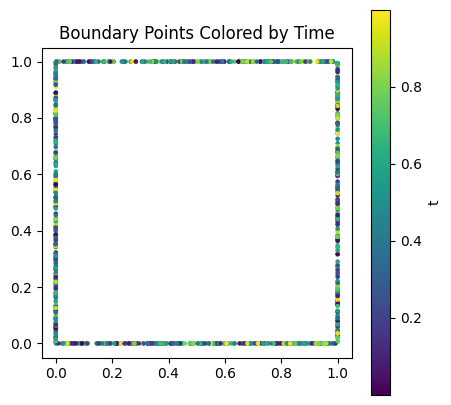

In [24]:
x = X_b[:, 0].detach().numpy()
y = X_b[:, 1].detach().numpy()
t = X_b[:, 2].detach().numpy()

plt.figure(figsize=(5,5))
plt.scatter(x, y, c=t, s=5, cmap='viridis')
plt.colorbar(label="t")
plt.gca().set_aspect('equal')
plt.title("Boundary Points Colored by Time")
plt.show()

torch.Size([200, 2])


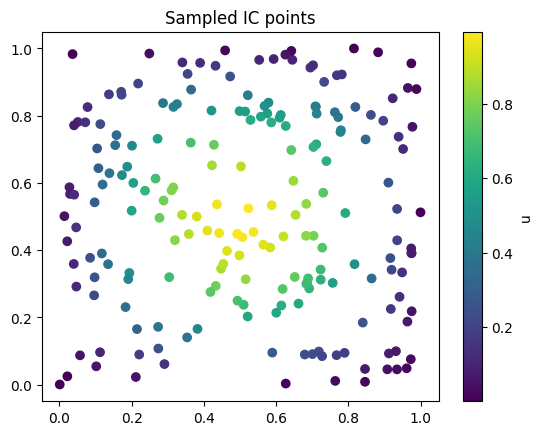

In [ ]:
plt.scatter(x_init[:,0], x_init[:,1], c=U_init.squeeze(), cmap='viridis')
plt.colorbar(label="u")
plt.title("Sampled IC points")
plt.show()

In [19]:
model = neural.FCN(3,1,6,20)

model



FCN(
  (fcs): Sequential(
    (0): Linear(in_features=3, out_features=6, bias=True)
    (1): Tanh()
  )
  (fch): Sequential(
    (0): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): Tanh()
    )
    (1): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): Tanh()
    )
    (2): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): Tanh()
    )
    (3): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): Tanh()
    )
    (4): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): Tanh()
    )
    (5): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): Tanh()
    )
    (6): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): Tanh()
    )
    (7): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): Tanh()
    )
    (8): Sequential(
      (0): Lin

In [ ]:
def make_heat_2d_residual(alpha):

    def residual_fn(X, u, grad_u):
        u_x = grad_u[:, 0:1]
        u_y = grad_u[:, 1:2]
        u_t = grad_u[:, 2:3]

        grad_u_x = neural.gradients(u_x, X)
        grad_u_y = neural.gradients(u_y, X)

        u_xx = grad_u_x[:, 0:1]
        u_yy = grad_u_y[:, 1:2]

        return u_t - alpha * (u_xx + u_yy)

    return residual_fn

residual_fn = make_heat_2d_residual(0.1)

<function __main__.make_heat_2d_residual.<locals>.residual_fn(X, u, grad_u)>

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
X_data = torch.cat([X_b,X_init], dim = 0)
U_data = torch.cat([U_b, U_init], dim=0)

neural.train(50000, optimizer, X_data, U_data, model, residual_fn, 1, 3, 1000)